# Part 3: Predictive Analysis - ver3 (SVR - RBF Kernel)

Dùng **Support Vector Regression với kernel RBF** làm baseline phi tuyến khác kiểu (kernel method, không phải cây quyết định), để so sánh với Random Forest và XGBoost (`train_model_ver2.ipynb`). Dùng chung bộ 7 numeric feature của **ver2**.

**Lưu ý quan trọng:** SVR rất nhạy với thang đo - không chỉ feature (`X`) mà cả **target (`y`)** cũng cần chuẩn hóa, vì tham số `epsilon` (biên sai số chấp nhận được) mặc định = 0.1, quá nhỏ so với `quantity_sold` (dao động 0-24,847) nếu không scale y trước.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

In [2]:
DATA_PATH = os.path.join("..", "Merge_Datasets", "merged_products.csv")
FIG_DIR = "figures_ver3"
OUT_DIR = "output_ver3"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42

NUMERIC_FEATURES = [
    "price",
    "discount_rate",
    "rating_average",
    "review_counts",
    "number_of_images",
    "vnd_cashback",
    "date_created",
]  # giống ver2 - đã bỏ favorite_count (variance=0) và original_price (corr 0.975 với price)
BOOL_FEATURES = ["pay_later", "has_video", "is_branded"]
CATEGORICAL_FEATURES = ["sub_category", "fulfillment_type"]
TARGET = "quantity_sold"

df = pd.read_csv(DATA_PATH)
df.shape

(41576, 21)

## 1. Chuẩn bị dữ liệu cho mô hình

In [3]:
def build_feature_matrix(df: pd.DataFrame):
    X = df[NUMERIC_FEATURES + BOOL_FEATURES].copy()
    for col in BOOL_FEATURES:
        X[col] = X[col].astype(int)

    dummies = pd.get_dummies(df[CATEGORICAL_FEATURES], prefix=CATEGORICAL_FEATURES).astype(int)

    X = pd.concat([X, dummies], axis=1)
    y = df[TARGET].astype(float)
    return X, y


X, y = build_feature_matrix(df)
X.shape

(41576, 20)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# scale feature (X)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

# scale target (y) - bắt buộc với SVR vì epsilon mặc định quá nhỏ so với thang đo quantity_sold
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()

print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Train rows: 33260, Test rows: 8316


## 2. Xây dựng và Đánh giá Mô hình SVR (RBF)

Train trên `y` đã scale, sau đó `inverse_transform` dự đoán về lại thang đo gốc của `quantity_sold` trước khi tính RMSE/R² - để so sánh công bằng với Random Forest/XGBoost (vốn tính RMSE/R² trên thang đo gốc).

In [5]:
svr_model = SVR(kernel="rbf", C=1.0, epsilon=0.1, gamma="scale")
svr_model.fit(X_train_scaled, y_train_scaled)

y_pred_scaled = svr_model.predict(X_test_scaled)
y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"SVR (RBF) - RMSE (test): {rmse:.2f}")
print(f"SVR (RBF) - R2 Score (test): {r2:.4f}")
print(f"Support vectors: {svr_model.support_vectors_.shape[0]} / {len(X_train_scaled)} train rows "
      f"({100*svr_model.support_vectors_.shape[0]/len(X_train_scaled):.1f}%)")

with open(os.path.join(OUT_DIR, "model_performance.txt"), "w") as f:
    f.write("=== Part 3 ver3: Predictive Analysis - SVR (RBF) Performance ===\n\n")
    f.write(f"Numeric features: {NUMERIC_FEATURES}\n")
    f.write(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}\n\n")
    f.write("Model: SVR(kernel='rbf', C=1.0, epsilon=0.1, gamma='scale')\n")
    f.write(f"Support vectors: {svr_model.support_vectors_.shape[0]} / {len(X_train_scaled)}\n\n")
    f.write(f"RMSE (test): {rmse:.2f}\n")
    f.write(f"R2 (test): {r2:.4f}\n")

SVR (RBF) - RMSE (test): 285.07
SVR (RBF) - R2 Score (test): 0.0853
Support vectors: 3538 / 33260 train rows (10.6%)


**Lưu ý:** SVR (kernel RBF) là kernel method - không có hệ số/`feature_importances_` trực tiếp như OLS hay model cây, nên phần này không vẽ được chart diễn giải theo từng feature như 2 model kia.

## 3. So sánh 3 model: SVR (RBF) vs. Random Forest vs. XGBoost

Đọc lại RMSE/R² đã lưu từ `train_model_ver2.ipynb` (Random Forest & XGBoost, cùng bộ feature ver2) để so sánh công bằng (apples-to-apples) với SVR ở trên.

           model        rmse        r2
0        SVR_rbf  285.069471  0.085253
1  random_forest  257.150000  0.255700
2        xgboost  256.780000  0.257800


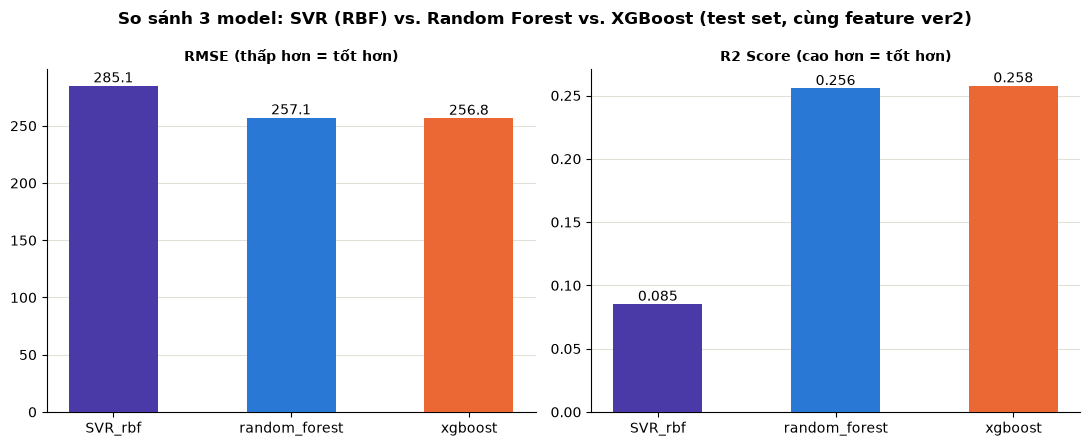

In [6]:
import re

with open(os.path.join("output_ver2", "model_performance.txt")) as f:
    ver2_text = f.read()

def extract(name, text):
    block = text.split(f"--- {name} ---")[1]
    rmse_v = float(re.search(r"RMSE: ([\d.]+)", block).group(1))
    r2_v = float(re.search(r"R2 Score: ([\d.]+)", block).group(1))
    return rmse_v, r2_v

rf_rmse, rf_r2 = extract("random_forest", ver2_text)
xgb_rmse, xgb_r2 = extract("xgboost", ver2_text)

comparison = pd.DataFrame({
    "model": ["SVR_rbf", "random_forest", "xgboost"],
    "rmse": [rmse, rf_rmse, xgb_rmse],
    "r2": [r2, rf_r2, xgb_r2],
})
print(comparison)

colors3 = {"SVR_rbf": "#4a3aa7", "random_forest": "#2a78d6", "xgboost": "#eb6834"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
bars = axes[0].bar(comparison["model"], comparison["rmse"],
                    color=[colors3[m] for m in comparison["model"]], width=0.5, zorder=3)
for b, v in zip(bars, comparison["rmse"]):
    axes[0].text(b.get_x() + b.get_width() / 2, v, f"{v:.1f}", ha="center", va="bottom", fontsize=10)
axes[0].set_title("RMSE (thấp hơn = tốt hơn)", fontsize=10, weight="bold")
axes[0].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)

bars = axes[1].bar(comparison["model"], comparison["r2"],
                    color=[colors3[m] for m in comparison["model"]], width=0.5, zorder=3)
for b, v in zip(bars, comparison["r2"]):
    axes[1].text(b.get_x() + b.get_width() / 2, v, f"{v:.3f}", ha="center", va="bottom", fontsize=10)
axes[1].set_title("R2 Score (cao hơn = tốt hơn)", fontsize=10, weight="bold")
axes[1].grid(axis="y", color="#e1e0d9", linewidth=0.8, zorder=0)

for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.set_axisbelow(True)

fig.suptitle("So sánh 3 model: SVR (RBF) vs. Random Forest vs. XGBoost (test set, cùng feature ver2)",
             fontsize=12, weight="bold")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "model_comparison_3way.png"), dpi=150)
plt.show()

comparison.to_csv(os.path.join(OUT_DIR, "model_comparison_3way.csv"), index=False)